<a href="https://colab.research.google.com/github/kyrax-sys/shevanti-hybrid-ai/blob/main/notebooks/Shevanthi_arima_run.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/kyrax-sys/shevanti-hybrid-ai.git
%cd shevanti-hybrid-ai
!git pull

import sys
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append('/content/shevanti-hybrid-ai/src')
from shared_utils import load_and_clean_data, get_splits, evaluate

df = load_and_clean_data('/content/shevanti-hybrid-ai/data/processed/Flower_price_2010-16_combined.csv')
print(df.shape)


fatal: destination path 'shevanti-hybrid-ai' already exists and is not an empty directory.
/content/shevanti-hybrid-ai
Already up to date.
(2557, 3)


Duplicate dates : 0
Missing prices  : 0
Zero/negative   : 0
Missing calendar days: 0
count    2557.000000
mean      359.711381
std       220.992373
min        10.000000
25%       170.000000
50%       310.000000
75%       460.000000
max       820.000000
Name: price, dtype: float64


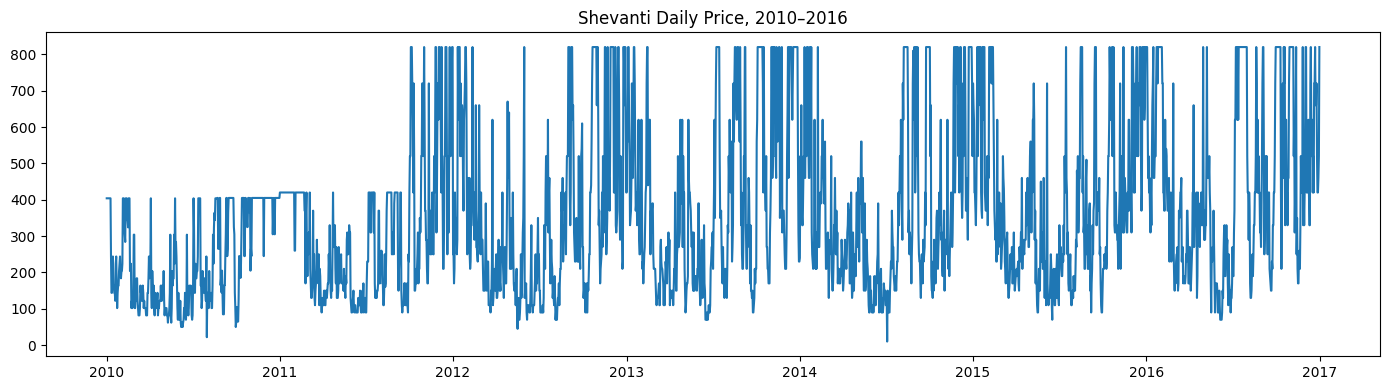

In [2]:
print("Duplicate dates :", df['date'].duplicated().sum())
print("Missing prices  :", df['price'].isna().sum())
print("Zero/negative   :", (df['price'] <= 0).sum())
full_range = pd.date_range(df['date'].min(), df['date'].max())
missing_days = full_range.difference(df['date'])
print("Missing calendar days:", len(missing_days))
print(df['price'].describe())

plt.figure(figsize=(14, 4))
plt.plot(df['date'], df['price'])
plt.title('Shevanti Daily Price, 2010–2016')
plt.tight_layout()
plt.show()


## Stage 2: Define the Forecasting Task

The primary forecasting task is to **predict tomorrow's Shevanti flower price** using information available up to and including today. This means that any features derived for prediction must not include future price information. The target variable will be the price on the next day.

In [3]:

df.dropna(subset=['target'], inplace=True)

print(f"Shape of dataframe after dropping rows with missing target: {df.shape}")


display(df.tail())

Shape of dataframe after dropping rows with missing target: (2556, 3)


,date,price,target
2551,2016-12-26,520.0,420.0
2552,2016-12-27,420.0,420.0
2553,2016-12-28,420.0,460.0
2554,2016-12-29,460.0,520.0
2555,2016-12-30,520.0,820.0


## Stage 3: Create Price-History Features

This stage involves generating useful features from the historical price series. These features will provide the model with context about past price movements. We will create:
- Lagged prices (prices from previous days)
- Recent averages (e.g., 3-day, 7-day, 30-day moving averages)
- Recent minimums and maximums
- Recent percentage changes

The goal is to create a purposeful set of features without overcomplicating the model with too many variables.

In [4]:

for i in range(1, 8):
    df[f'price_lag_{i}'] = df['price'].shift(i)


df['price_ma_3'] = df['price'].rolling(window=3, closed='left').mean()
df['price_ma_7'] = df['price'].rolling(window=7, closed='left').mean()
df['price_ma_30'] = df['price'].rolling(window=30, closed='left').mean()


df['price_min_7'] = df['price'].rolling(window=7, closed='left').min()
df['price_max_7'] = df['price'].rolling(window=7, closed='left').max()

df['price_pct_change_1'] = df['price'].pct_change(1)
df['price_pct_change_7'] = df['price'].pct_change(7)

df.dropna(inplace=True)

print(f"Shape of dataframe after feature creation and dropping NaNs: {df.shape}")
display(df.head())

Shape of dataframe after feature creation and dropping NaNs: (2526, 17)


,date,price,target,price_lag_1,price_lag_2,price_lag_3,price_lag_4,price_lag_5,price_lag_6,price_lag_7,price_ma_3,price_ma_7,price_ma_30,price_min_7,price_max_7,price_pct_change_1,price_pct_change_7
30,2010-01-31,184.0,202.0,204.0,244.0,224.0,204.0,164.0,164.0,144.0,224.000000,192.571429,247.200000,144.0,244.0,-0.098039,0.277778
31,2010-02-01,202.0,204.0,184.0,204.0,244.0,224.0,204.0,164.0,164.0,210.666667,198.285714,239.866667,164.0,244.0,0.097826,0.231707
32,2010-02-02,204.0,224.0,202.0,184.0,204.0,244.0,224.0,204.0,164.0,196.666667,203.714286,233.133333,164.0,244.0,0.009901,0.243902
33,2010-02-03,224.0,404.0,204.0,202.0,184.0,204.0,244.0,224.0,204.0,196.666667,209.428571,226.466667,184.0,244.0,0.098039,0.098039
34,2010-02-04,404.0,404.0,224.0,204.0,202.0,184.0,204.0,244.0,224.0,210.000000,212.285714,220.466667,184.0,244.0,0.803571,0.803571


## Stage 4: Build Simple Baselines

Before diving into complex AI models, it's crucial to establish simple baseline forecasts. These baselines provide a reference point to evaluate whether a more sophisticated model is truly adding value. We will implement two baselines:

1.  **Naive Forecast**: "Tomorrow's price is the same as today's price."
2.  **Recent Average Forecast**: "Tomorrow's price is the average of the last few days' prices." (We'll use the 3-day moving average `price_ma_3` for this).

We will evaluate these baselines using Mean Absolute Error (MAE).

In [5]:

df['baseline_naive'] = df['price_lag_1']


df['baseline_ma_3'] = df['price_ma_3']


mae_naive = (df['target'] - df['baseline_naive']).abs().mean()
mae_ma_3 = (df['target'] - df['baseline_ma_3']).abs().mean()

print(f"Naive Baseline MAE: {mae_naive:.2f}")
print(f"3-Day Moving Average Baseline MAE: {mae_ma_3:.2f}")


display(df[['date', 'price', 'target', 'baseline_naive', 'baseline_ma_3']].tail())

Naive Baseline MAE: 110.42
3-Day Moving Average Baseline MAE: 117.99


,date,price,target,baseline_naive,baseline_ma_3
2551,2016-12-26,520.0,420.0,720.0,680.000000
2552,2016-12-27,420.0,420.0,520.0,633.333333
2553,2016-12-28,420.0,460.0,420.0,553.333333
2554,2016-12-29,460.0,520.0,420.0,453.333333
2555,2016-12-30,520.0,820.0,460.0,433.333333


## Stage 5: Build the Statistical Model (ARIMA)

We build a classical time-series forecasting model (ARIMA) using `pmdarima.AutoARIMA` to find the best (p, d, q) automatically on the training data.

**Important methodological note:** ARIMA must be evaluated with a **rolling one-step-ahead forecast** — i.e. forecast tomorrow using everything known up to today, then feed in the real observed price before forecasting the next day. Asking `model.predict(n_periods=len(test_data))` for the *entire* test period in a single shot (the earlier version of this notebook) is a different, much harder task: with no new information ever fed back in, a multi-step ARIMA forecast mathematically collapses toward the series' long-run mean as the horizon grows. That is why the original run produced the exact same forecast value for every day of the test set. The fix below forecasts one day at a time and updates the model with the real price after each day, matching the same "use info up to today, predict tomorrow" task that the XGBoost model is evaluated on.


In [6]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 6.4 MB/s eta 0:00:00


In [7]:
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


df_arima = df.set_index('date')['price']


train_size = int(len(df_arima) * 0.8)
train_data, test_data = df_arima[0:train_size], df_arima[train_size:]

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")


model = auto_arima(train_data, seasonal=False, suppress_warnings=True,
                    stepwise=True, trace=True, error_action='ignore')

print("\nARIMA Model Summary:")
print(model.summary())


Train data shape: (2020,)
Test data shape: (506,)
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=25011.822, Time=8.18 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=25229.509, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=25160.455, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=25136.547, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=25227.510, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=25011.729, Time=2.75 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=25102.492, Time=0.79 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=25019.708, Time=1.66 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=25012.273, Time=2.81 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=25082.999, Time=1.10 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=25012.497, Time=1.69 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=25015.668, Time=2.90 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=25009.735, Time=0.86 sec
 ARIMA(0,1,2)(0,0,0)[0]             

In [8]:

rolling_preds = []

for actual_price in test_data:
    yhat = model.predict(n_periods=1)[0]
    rolling_preds.append(yhat)


    model.update([actual_price])

forecast_series = pd.Series(rolling_preds, index=test_data.index)


def smape(actual, pred):
    return np.mean(2 * np.abs(pred - actual) / (np.abs(actual) + np.abs(pred))) * 100

mae_arima    = mean_absolute_error(test_data, forecast_series)
rmse_arima   = np.sqrt(mean_squared_error(test_data, forecast_series))
smape_arima  = smape(test_data.values, forecast_series.values)
diracc_arima = (np.sign(np.diff(test_data.values)) ==
                np.sign(np.diff(forecast_series.values))).mean() * 100

print(f"ARIMA (rolling 1-step) MAE   : {mae_arima:.2f}")
print(f"ARIMA (rolling 1-step) RMSE  : {rmse_arima:.2f}")
print(f"ARIMA (rolling 1-step) sMAPE : {smape_arima:.2f}%")
print(f"ARIMA (rolling 1-step) DirAcc: {diracc_arima:.2f}%")




/tmp/ipykernel_5752/2070538533.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  yhat = model.predict(n_periods=1)[0]


ARIMA (rolling 1-step) MAE   : 101.06
ARIMA (rolling 1-step) RMSE  : 137.32
ARIMA (rolling 1-step) sMAPE : 24.32%
ARIMA (rolling 1-step) DirAcc: 29.31%


In [9]:



naive_pred_matched = test_data.shift(1)
naive_pred_matched.iloc[0] = train_data.iloc[-1]


combined = pd.concat([train_data, test_data])
ma7_matched = combined.rolling(window=7, closed='left').mean().loc[test_data.index]

def smape_arr(actual, pred):
    return np.mean(2 * np.abs(pred - actual) / (np.abs(actual) + np.abs(pred))) * 100

def diracc_arr(actual, pred):
    return (np.sign(np.diff(actual)) == np.sign(np.diff(pred))).mean() * 100

rows = []
for name, pred in [
    ("Naive (today)",  naive_pred_matched),
    ("7-day average",  ma7_matched),
    ("ARIMA (rolling 1-step)", forecast_series),
]:
    rows.append({
        "model": name,
        "MAE":   mean_absolute_error(test_data, pred),
        "RMSE":  np.sqrt(mean_squared_error(test_data, pred)),
        "sMAPE": smape_arr(test_data.values, pred.values),
        "DirAcc": diracc_arr(test_data.values, pred.values),
    })

arima_results_df = pd.DataFrame(rows)
arima_results_df


,model,MAE,RMSE,sMAPE,DirAcc
0,Naive (today),95.434783,145.356995,23.342014,34.653465
1,7-day average,133.167702,174.244147,32.247712,37.227723
2,ARIMA (rolling 1-step),101.059985,137.321739,24.322896,29.306931


In [10]:

forecast_df_to_merge = forecast_series.to_frame(name='arima_forecast')
forecast_df_to_merge.index.name = 'date'
df = df.merge(forecast_df_to_merge, on='date', how='left')

display(df[['date', 'price', 'target', 'arima_forecast']].tail())


,date,price,target,arima_forecast
2521,2016-12-26,520.0,420.0,681.210431
2522,2016-12-27,420.0,420.0,545.099606
2523,2016-12-28,420.0,460.0,456.332284
2524,2016-12-29,460.0,520.0,444.444725
2525,2016-12-30,520.0,820.0,471.001407


In [11]:

predictions_arima = test_data.to_frame(name='actual')
predictions_arima['pred_arima'] = forecast_series
predictions_arima = predictions_arima.reset_index().rename(columns={'index': 'date'})

predictions_arima.to_csv(
    '/content/shevanti-hybrid-ai/results/tables/predictions_arima.csv',
    index=False
)

predictions_arima.tail()


,date,actual,pred_arima
501,2016-12-26,520.0,681.210431
502,2016-12-27,420.0,545.099606
503,2016-12-28,420.0,456.332284
504,2016-12-29,460.0,444.444725
505,2016-12-30,520.0,471.001407


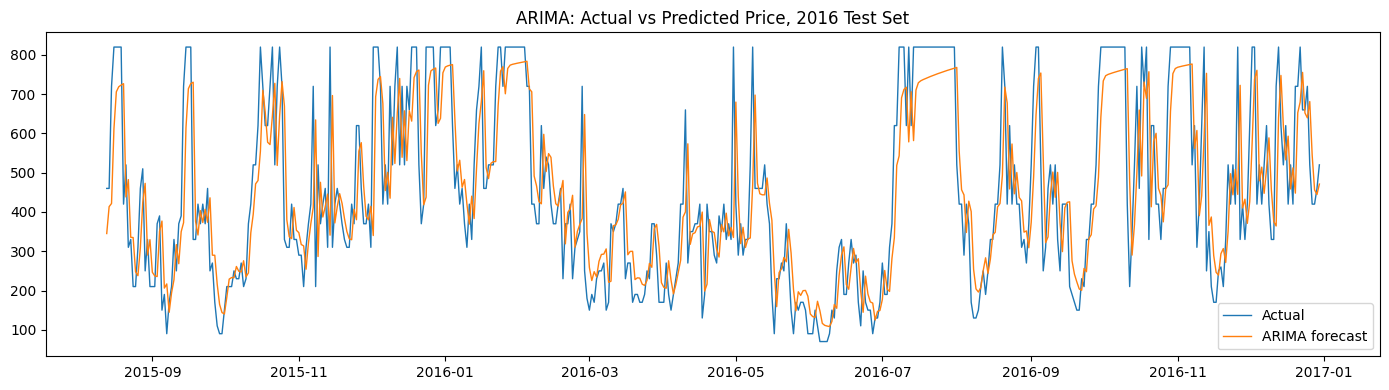

In [12]:
plt.figure(figsize=(14, 4))
plt.plot(test_data.index, test_data.values, label='Actual', linewidth=1)
plt.plot(forecast_series.index, forecast_series.values, label='ARIMA forecast', linewidth=1)
plt.legend()
plt.title('ARIMA: Actual vs Predicted Price, 2016 Test Set')
plt.tight_layout()
plt.show()


In [13]:
!git config --global user.name "Sujan0310"
!git config --global user.email "sujan3102004@gmail.com"

In [14]:
!git add results/tables/predictions_arima.csv
!git commit -m "Add ARIMA predictions"


[main 181a982] Add ARIMA predictions
 1 file changed, 507 insertions(+)
 create mode 100644 results/tables/predictions_arima.csv


In [16]:
from getpass import getpass
token = getpass("Enter GitHub token: ")
!git remote set-url origin https://<Sujan0310>:{token}@github.com/kyrax-sys/shevanti-hybrid-ai.git
!git push origin main

Enter GitHub token: ··········
/bin/bash: line 1: Sujan0310: No such file or directory
Enumerating objects: 8, done.
Counting objects: 100% (8/8), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 7.25 KiB | 7.25 MiB/s, done.
Total 5 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/kyrax-sys/shevanti-hybrid-ai.git
   8eae31f..181a982  main -> main
